In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import linregress, pearsonr
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## Load and Explore Dataset
We start by loading the dataset and checking its structure (countries, years, variables).  
This ensures we understand the scope of the data before analysis.


In [ ]:
# Load the climate change dataset
df = pd.read_csv('climate_change_dataset.csv')

# Display basic information
print("DATASET OVERVIEW")
print(f"Dataset Shape: {df.shape}")
print(f"Countries: {df['Country'].nunique()}")
print(f"Years: {df['Year'].min()} to {df['Year'].max()}")
print(f"Total Records: {len(df)}")

# Show first few rows
print("\nFirst 5 rows:")
display(df.head())

# Check data types
print("\nData Types:")
print(df.dtypes)

DATASET OVERVIEW
Dataset Shape: (1000, 10)
Countries: 15
Years: 2000 to 2023
Total Records: 1000

First 5 rows:


,Year,Country,Avg Temperature (°C),CO2 Emissions (Tons/Capita),Sea Level Rise (mm),Rainfall (mm),Population,Renewable Energy (%),Extreme Weather Events,Forest Area (%)
0,2006,UK,8.9,9.3,3.1,1441,530911230,20.4,14,59.8
1,2019,USA,31.0,4.8,4.2,2407,107364344,49.2,8,31.0
2,2014,France,33.9,2.8,2.2,1241,441101758,33.3,9,35.5
3,2010,Argentina,5.9,1.8,3.2,1892,1069669579,23.7,7,17.7
4,2007,Germany,26.9,5.6,2.4,1743,124079175,12.5,4,17.4



Data Types:
Year                             int64
Country                         object
Avg Temperature (°C)           float64
CO2 Emissions (Tons/Capita)    float64
Sea Level Rise (mm)            float64
Rainfall (mm)                    int64
Population                       int64
Renewable Energy (%)           float64
Extreme Weather Events           int64
Forest Area (%)                float64
dtype: object


## Data Quality Check
We inspect missing values, duplicates, and country coverage.  
This ensures the dataset is clean and reliable before deeper analysis.


In [ ]:
missing_data = df.isnull().sum()
print("Missing values:", missing_data.sum())
print("Duplicates:", df.duplicated().sum())
df['Country'].value_counts().head(10)

Missing values: 0
Duplicates: 0


,count
Country,
Indonesia,75
Russia,74
USA,73
South Africa,73
India,70
China,67
Argentina,67
Canada,67
Brazil,67


## Summary Statistics
We calculate descriptive statistics for climate indicators.  
This provides a quick overview of data distributions and ranges.


In [ ]:
numerical_cols = ['Avg Temperature (°C)', 'CO2 Emissions (Tons/Capita)',
                 'Sea Level Rise (mm)', 'Rainfall (mm)',
                 'Renewable Energy (%)', 'Extreme Weather Events', 'Forest Area (%)']

df[numerical_cols].describe().round(2)


,Avg Temperature (°C),CO2 Emissions (Tons/Capita),Sea Level Rise (mm),Rainfall (mm),Renewable Energy (%),Extreme Weather Events,Forest Area (%)
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,19.88,10.43,3.01,1738.76,27.30,7.29,40.57
std,8.54,5.61,1.15,708.98,12.97,4.42,17.40
min,5.00,0.50,1.00,501.00,5.10,0.00,10.10
25%,12.18,5.57,2.00,1098.75,16.10,3.00,25.60
50%,20.10,10.70,3.00,1726.00,27.15,8.00,41.15
75%,27.22,15.40,4.00,2362.50,38.92,11.00,55.80
max,34.90,20.00,5.00,2999.00,50.00,14.00,70.00


## Global Climate Trends (2000–2023)
We now check global trends in emissions, temperature, renewables, and sea level  
to detect long-term shifts and identify progress or regression.


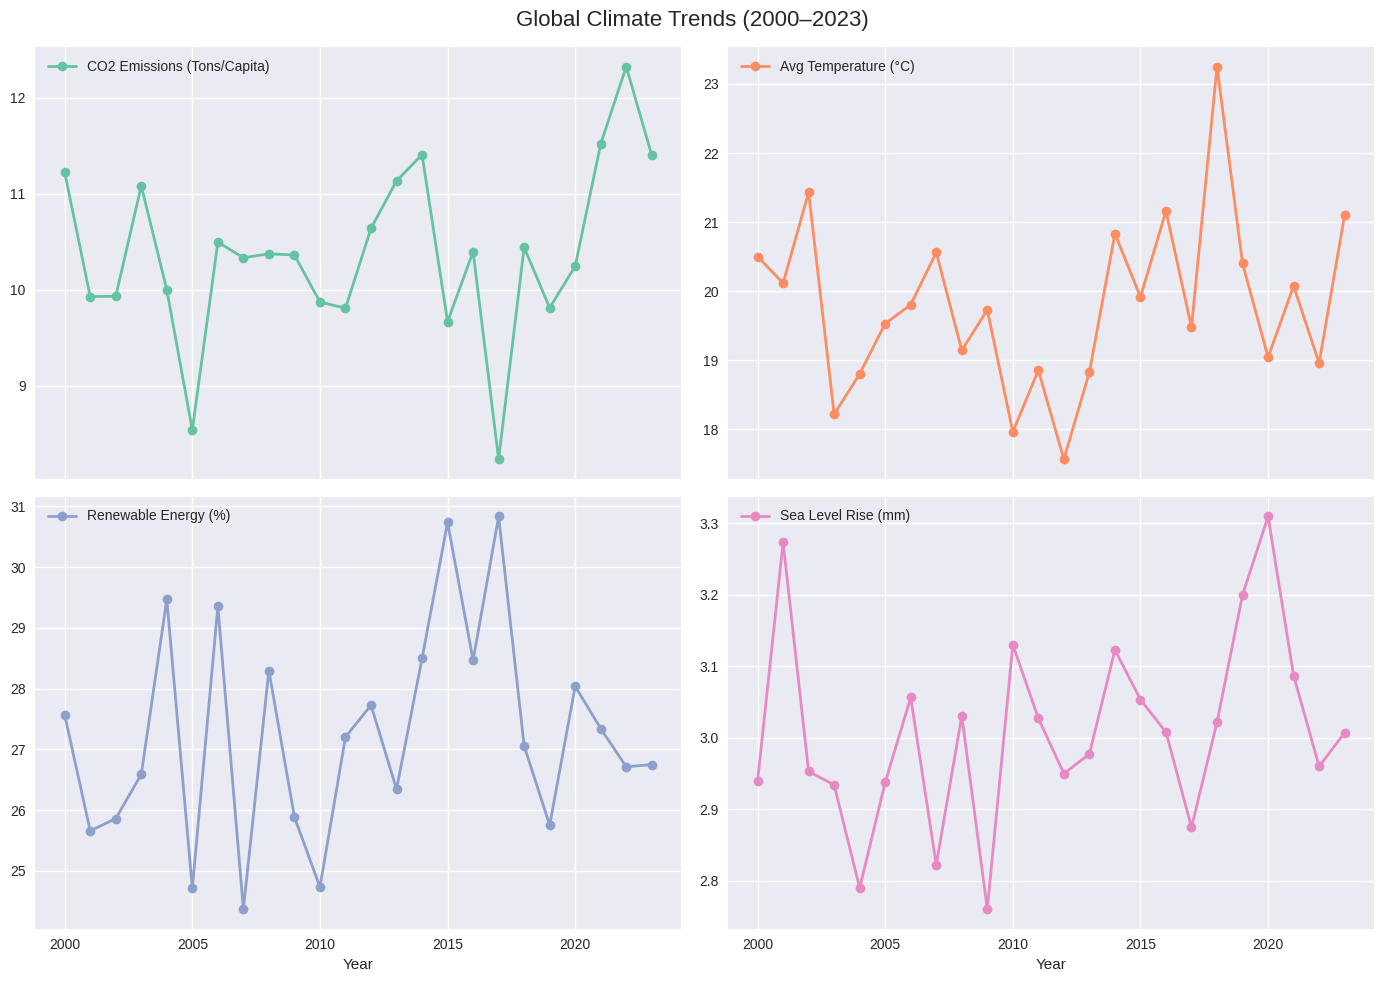

In [ ]:
yearly_trends = df.groupby('Year')[['CO2 Emissions (Tons/Capita)',
                                   'Avg Temperature (°C)',
                                   'Renewable Energy (%)',
                                   'Sea Level Rise (mm)']].mean()

yearly_trends.plot(subplots=True, layout=(2,2), figsize=(14,10), marker='o', linewidth=2)
plt.suptitle("Global Climate Trends (2000–2023)", fontsize=16)
plt.tight_layout()
plt.show()


## Country Rankings
We rank countries to identify both leaders and laggards in sustainability.  
This highlights who sets the benchmark and who needs urgent intervention.


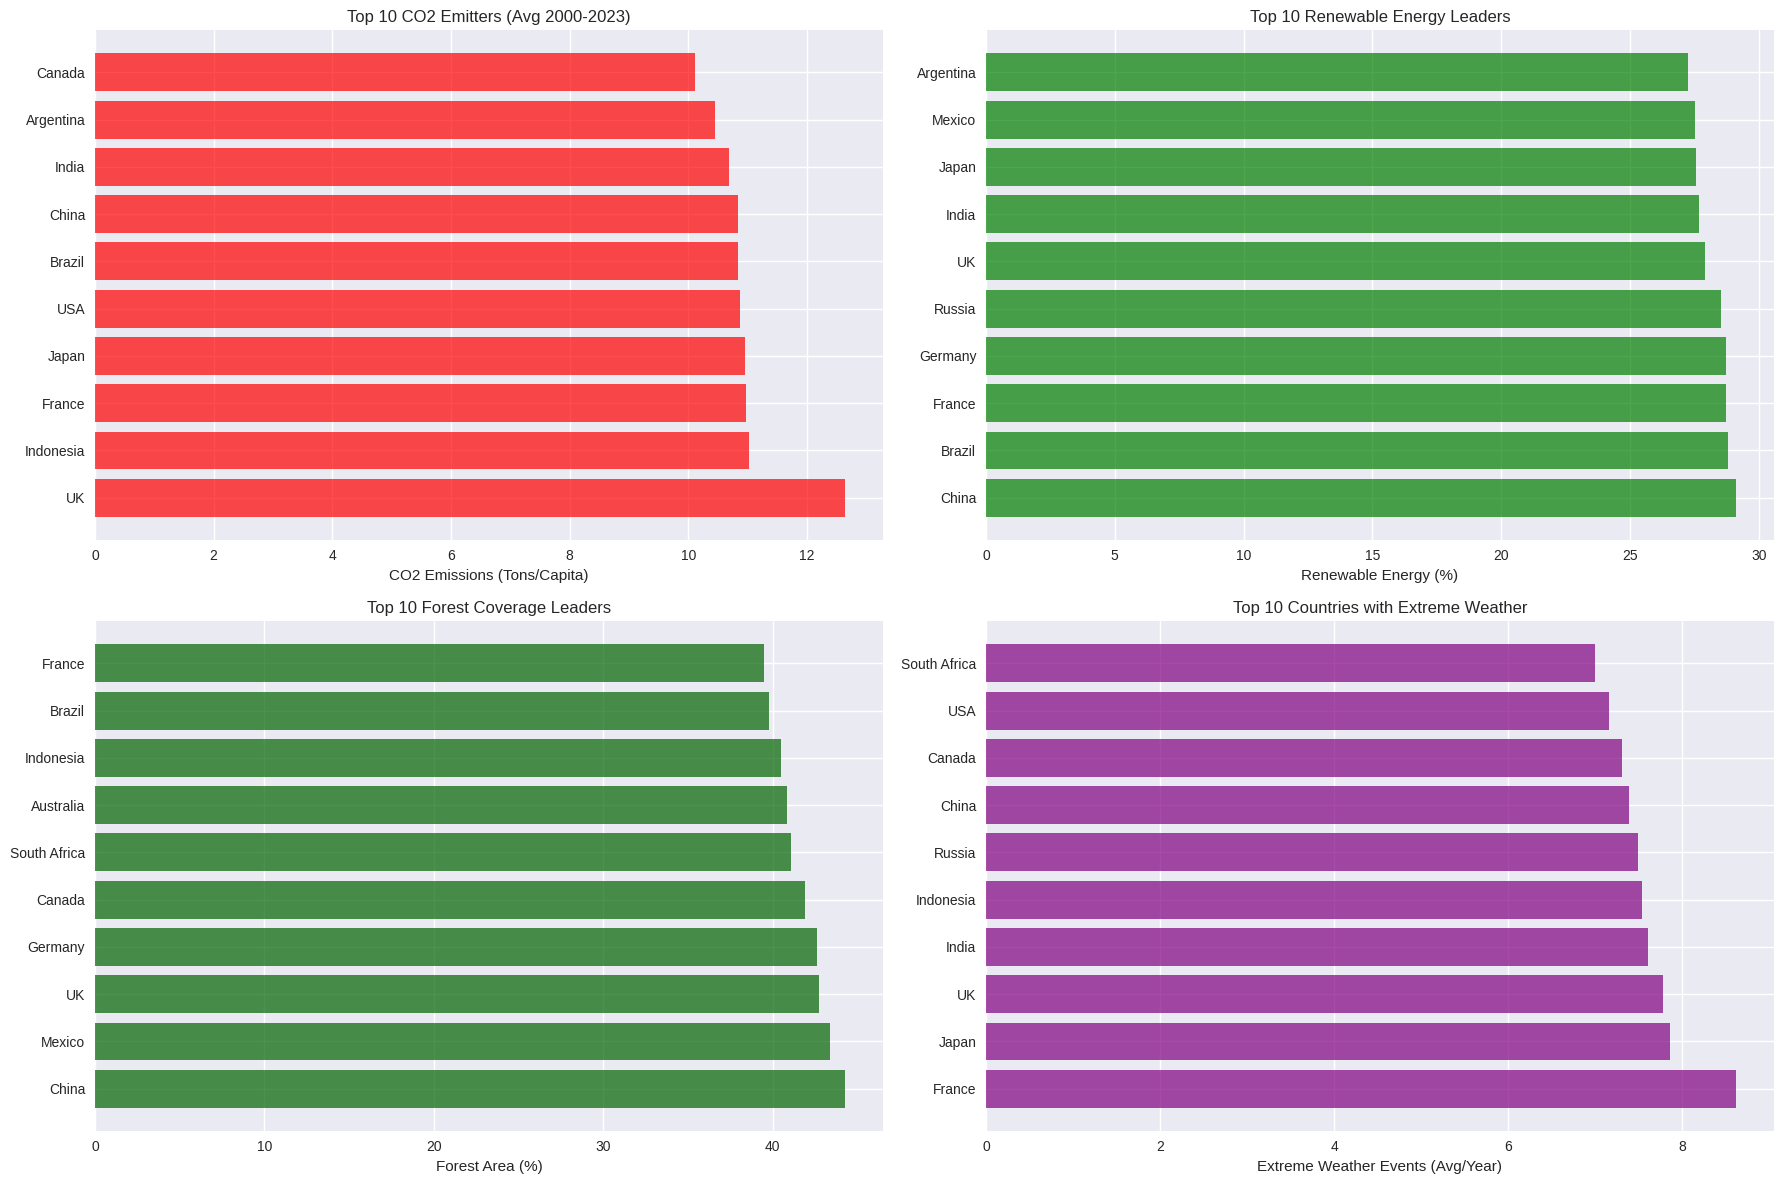


TOP PERFORMERS:
Highest CO2: UK (12.65 tons/capita)
Most Renewable: China (29.1%)
Most Forest: China (44.3%)
Most Extreme Weather: France (8.6)


In [ ]:
# Calculate country averages
country_stats = df.groupby('Country').agg({
    'CO2 Emissions (Tons/Capita)': 'mean',
    'Renewable Energy (%)': 'mean',
    'Forest Area (%)': 'mean',
    'Extreme Weather Events': 'mean'
}).round(2)

# Create comparison plots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Top CO2 emitters
top_co2 = country_stats['CO2 Emissions (Tons/Capita)'].nlargest(10)
axes[0,0].barh(range(len(top_co2)), top_co2.values, color='red', alpha=0.7)
axes[0,0].set_yticks(range(len(top_co2)))
axes[0,0].set_yticklabels(top_co2.index)
axes[0,0].set_title('Top 10 CO2 Emitters (Avg 2000-2023)')
axes[0,0].set_xlabel('CO2 Emissions (Tons/Capita)')

# Top renewable energy adopters
top_renewable = country_stats['Renewable Energy (%)'].nlargest(10)
axes[0,1].barh(range(len(top_renewable)), top_renewable.values, color='green', alpha=0.7)
axes[0,1].set_yticks(range(len(top_renewable)))
axes[0,1].set_yticklabels(top_renewable.index)
axes[0,1].set_title('Top 10 Renewable Energy Leaders')
axes[0,1].set_xlabel('Renewable Energy (%)')

# Forest coverage leaders
top_forest = country_stats['Forest Area (%)'].nlargest(10)
axes[1,0].barh(range(len(top_forest)), top_forest.values, color='darkgreen', alpha=0.7)
axes[1,0].set_yticks(range(len(top_forest)))
axes[1,0].set_yticklabels(top_forest.index)
axes[1,0].set_title('Top 10 Forest Coverage Leaders')
axes[1,0].set_xlabel('Forest Area (%)')

# Countries with most extreme weather
top_extreme = country_stats['Extreme Weather Events'].nlargest(10)
axes[1,1].barh(range(len(top_extreme)), top_extreme.values, color='purple', alpha=0.7)
axes[1,1].set_yticks(range(len(top_extreme)))
axes[1,1].set_yticklabels(top_extreme.index)
axes[1,1].set_title('Top 10 Countries with Extreme Weather')
axes[1,1].set_xlabel('Extreme Weather Events (Avg/Year)')

plt.tight_layout()
plt.show()

print("\nTOP PERFORMERS:")
print(f"Highest CO2: {top_co2.index[0]} ({top_co2.iloc[0]:.2f} tons/capita)")
print(f"Most Renewable: {top_renewable.index[0]} ({top_renewable.iloc[0]:.1f}%)")
print(f"Most Forest: {top_forest.index[0]} ({top_forest.iloc[0]:.1f}%)")
print(f"Most Extreme Weather: {top_extreme.index[0]} ({top_extreme.iloc[0]:.1f})")

In [ ]:
country_stats = df.groupby('Country')[['CO2 Emissions (Tons/Capita)',
                                              'Renewable Energy (%)',
                                              'Forest Area (%)',
                                              'Extreme Weather Events']].mean()
country_stats.sort_values('CO2 Emissions (Tons/Capita)', ascending=False).head(10)

,CO2 Emissions (Tons/Capita),Renewable Energy (%),Forest Area (%),Extreme Weather Events
Country,,,,
UK,12.650769,27.920000,42.718462,7.784615
Indonesia,11.021333,26.529333,40.524000,7.533333
France,10.966667,28.739394,39.496970,8.621212
Japan,10.960317,27.560317,38.120635,7.857143
USA,10.882192,25.715068,38.534247,7.164384
Brazil,10.838806,28.786567,39.774627,6.880597
China,10.835821,29.129851,44.302985,7.388060
India,10.694286,27.694286,38.990000,7.600000
Argentina,10.447761,27.261194,38.832836,6.582090


## Climate Variable Correlations
We analyze correlations between key indicators — for example,  
whether higher renewable energy adoption is linked to lower CO2 emissions.


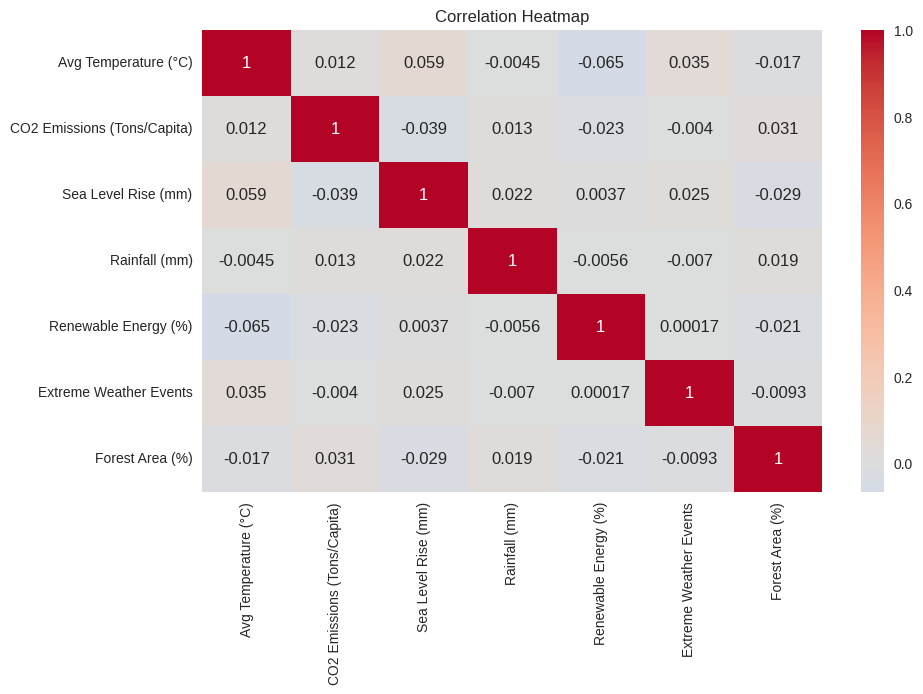


Strongest Correlations:
Avg Temperature (°C) ↔ Renewable Energy (%): -0.065 (negative)
Avg Temperature (°C) ↔ Sea Level Rise (mm): 0.059 (positive)
CO2 Emissions (Tons/Capita) ↔ Sea Level Rise (mm): -0.039 (negative)
Avg Temperature (°C) ↔ Extreme Weather Events: 0.035 (positive)
CO2 Emissions (Tons/Capita) ↔ Forest Area (%): 0.031 (positive)


In [ ]:
corr_matrix = df[numerical_cols].corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

# Find and display strongest correlations
print("\nStrongest Correlations:")
correlation_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        correlation_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], abs(corr_val), corr_val))

correlation_pairs.sort(key=lambda x: x[2], reverse=True)
for var1, var2, abs_corr, corr in correlation_pairs[:5]:
    direction = "positive" if corr > 0 else "negative"
    print(f"{var1} ↔ {var2}: {corr:.3f} ({direction})")

This correlation heatmap summarizes the linear relationships between key climate variables in the dataset, including temperature, CO₂ emissions, sea level rise, rainfall, renewables, extreme weather events, and forest area.


*   Interpretation: Most variables exhibit very weak or near-zero correlations with each other. No pair demonstrates a strong positive or negative linear relationship in this global, cross-country sample.

*   For example, CO₂ emissions per capita show almost no correlation with renewable energy share or forest area, and extreme weather events are not strongly linked to any particular climate metric in this data.

*   Implication: The multifaceted nature of climate systems and the diversity of country profiles likely dilute clear linear relationships in this aggregated view. Effective climate action may therefore require multifactor interventions, as single variable changes do not directly predict improvements in other climate outcomes.

## Renewable Energy vs CO2 Emissions
We test whether higher renewable adoption translates into lower CO2 emissions.  
This measures the effectiveness of green energy transitions.


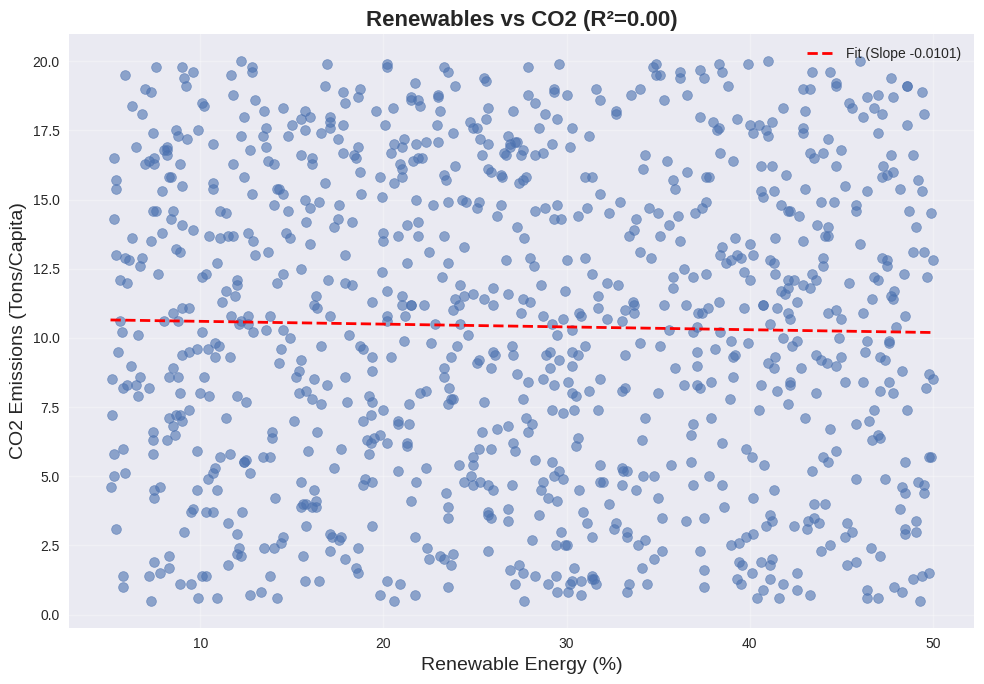


RELATIONSHIP ANALYSIS:
Correlation: -0.023
Slope: -0.0101 (CO2 change per 1% renewable increase)
P-value: 0.4607
No statistically significant relationship (see flat line and R² ~ 0)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress, pearsonr

# Scatter plot
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='Renewable Energy (%)', y='CO2 Emissions (Tons/Capita)', alpha=0.6, edgecolor=None)

# Regression line
x = np.linspace(df['Renewable Energy (%)'].min(), df['Renewable Energy (%)'].max(), 100)
slope, intercept, r, p, std_err = linregress(df['Renewable Energy (%)'], df['CO2 Emissions (Tons/Capita)'])
plt.plot(x, slope * x + intercept, 'r--', linewidth=2, label=f'Fit (Slope {slope:.4f})')

plt.title(f"Renewables vs CO2 (R²={r**2:.2f})", fontsize=16, fontweight='bold')
plt.xlabel('Renewable Energy (%)', fontsize=14)
plt.ylabel('CO2 Emissions (Tons/Capita)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print stats with strong formatting
print(f"\nRELATIONSHIP ANALYSIS:")
correlation_value, _ = pearsonr(df['Renewable Energy (%)'], df['CO2 Emissions (Tons/Capita)'])
print(f"Correlation: {correlation_value:.3f}")
print(f"Slope: {slope:.4f} (CO2 change per 1% renewable increase)")
print(f"P-value: {p:.4f}")
if p < 0.05:
    print("Statistically significant relationship")
else:
    print("No statistically significant relationship (see flat line and R² ~ 0)")


The data shows almost no linear relationship between renewables and CO2 — the scatter points are widely spread with a nearly flat regression line and R² near zero, which means renewable share does not predict CO2 reductions per capita at the cross-country level. This likely means factors like overall energy demand, fossil-fuel use, and economic structure are much stronger drivers of CO2 emissions than the marginal renewable increase alone.

## Forest Cover and Extreme Weather
Do countries with more forest cover suffer fewer extreme weather events?  
This analysis quantifies the ecosystem protection effect of forests.


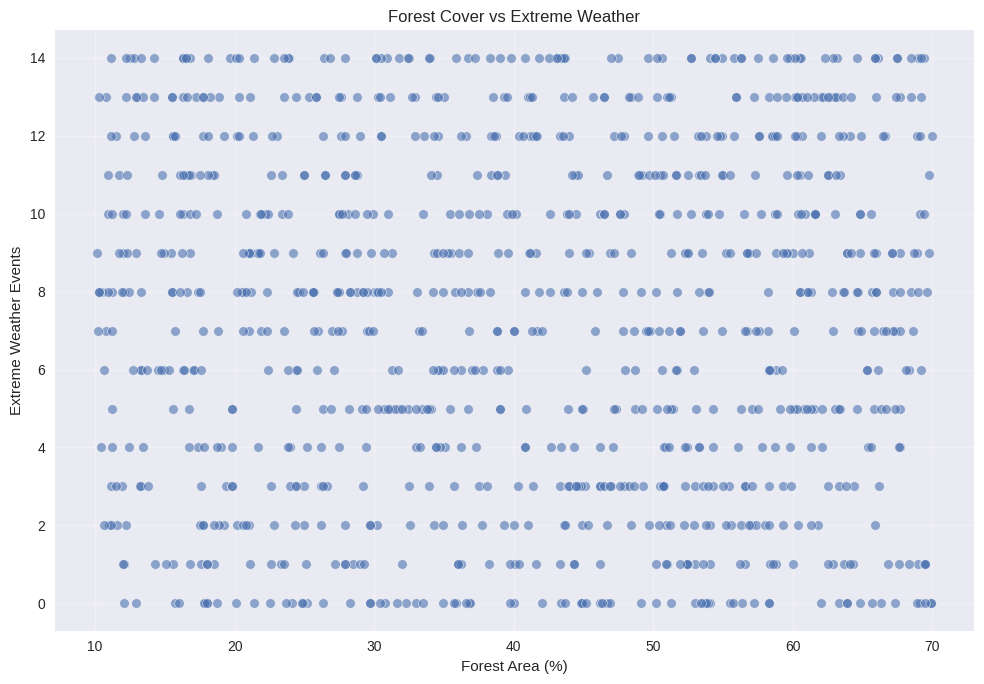


FOREST PROTECTION ANALYSIS:
Correlation coefficient (r): -0.009
Slope: -0.002 (events change per 1% forest increase)
P-value: 0.7692
No statistically significant relationship (see wide scatter and r ~ 0)
Low forest coverage: 7.4 events/year
High forest coverage: 7.3 events/year
Difference: 0.1 events/year


In [ ]:
# Scatterplot with grid
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='Forest Area (%)', y='Extreme Weather Events', alpha=0.6)
plt.title("Forest Cover vs Extreme Weather")
plt.xlabel("Forest Area (%)")
plt.ylabel("Extreme Weather Events")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Linear regression stats
slope_forest, intercept_forest, r_forest, p_forest, std_err_forest = linregress(
    df['Forest Area (%)'], df['Extreme Weather Events'])

print("\nFOREST PROTECTION ANALYSIS:")
print(f"Correlation coefficient (r): {r_forest:.3f}")
print(f"Slope: {slope_forest:.3f} (events change per 1% forest increase)")
print(f"P-value: {p_forest:.4f}")

if p_forest < 0.05:
    print("Statistically significant relationship")
else:
    print("No statistically significant relationship (see wide scatter and r ~ 0)")

# Categorize forest cover
bins = [0, 30, 50, 100]
labels = ['Low', 'Medium', 'High']
df['Forest_Group'] = pd.cut(df['Forest Area (%)'], bins=bins, labels=labels)

low_forest = df[df['Forest_Group'] == 'Low']['Extreme Weather Events'].mean()
high_forest = df[df['Forest_Group'] == 'High']['Extreme Weather Events'].mean()
diff_events = low_forest - high_forest
print(f"Low forest coverage: {low_forest:.1f} events/year")
print(f"High forest coverage: {high_forest:.1f} events/year")
print(f"Difference: {diff_events:.1f} events/year")


*   Correlation (r): Near zero, so forest cover isn't strongly linearly associated with the count of extreme weather events across the dataset.

*   Slope: Also near zero; indicates no systematic change in events per unit forest cover.

*   Statistics: P-value high (insignificant), so results are likely random; as visually evident in the scatterplot, there are no clear trends.

*   Group Means: The average number of events per year is nearly identical for low and high forest coverage groups (7.4 vs. 7.3). The difference is just 0.1 events/year, indicating little real-world separation in this dataset.

## Sustainability Dashboard
We combine multiple indicators into a single sustainability score  
to rank countries holistically on climate performance.


In [ ]:
country_stats['Sustainability_Score'] = (
    (100 - country_stats['CO2 Emissions (Tons/Capita)'].rank(pct=True)*100) +
    (country_stats['Renewable Energy (%)'].rank(pct=True)*100) +
    (country_stats['Forest Area (%)'].rank(pct=True)*100) -
    (country_stats['Extreme Weather Events'].rank(pct=True)*100)
) / 4

country_stats['Sustainability_Score'].sort_values(ascending=False).head(10)


,Sustainability_Score
Country,
Mexico,53.333333
Germany,50.000000
China,45.000000
Australia,36.666667
Brazil,35.000000
Russia,26.666667
Argentina,26.666667
South Africa,26.666667
Canada,26.666667


## Regional Climate Profiles
We compare continents and regions to see how climate impacts and responses differ globally.  
This reveals regional strengths and vulnerabilities.


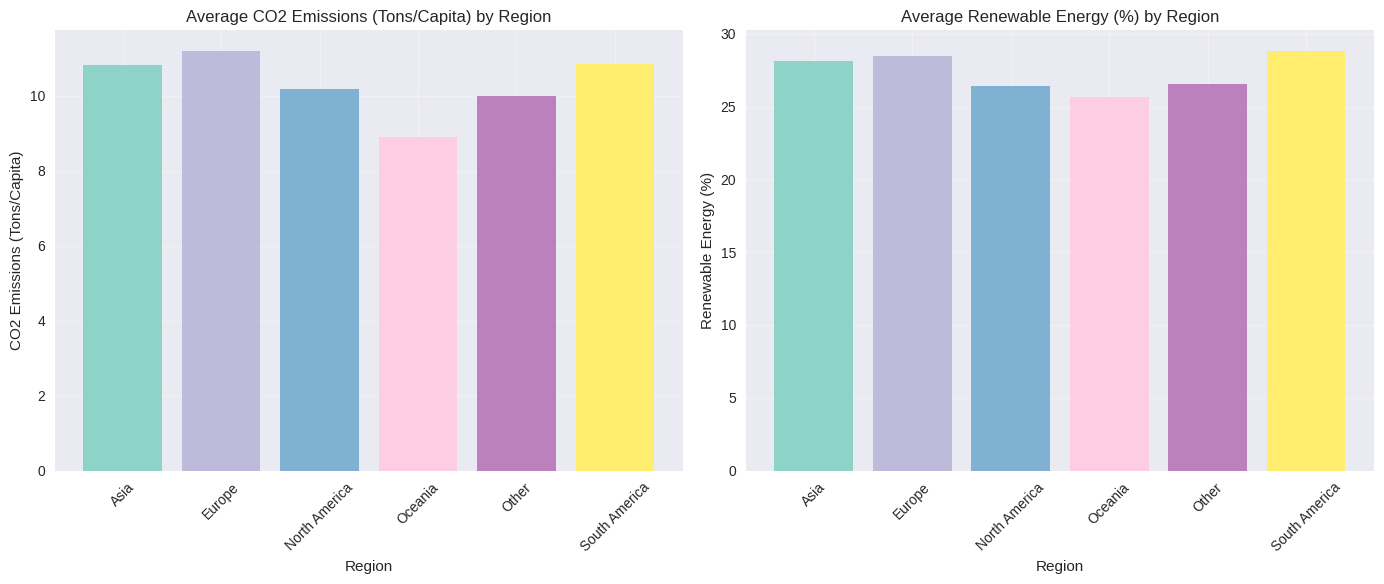


REGIONAL CLIMATE SUMMARY:
               CO2 Emissions (Tons/Capita)  Renewable Energy (%)
Region                                                          
Asia                                 10.83                 28.13
Europe                               11.19                 28.45
North America                        10.19                 26.41
Oceania                               8.90                 25.62
Other                                10.01                 26.55
South America                        10.84                 28.79


In [ ]:
region_mapping = {
    "USA": "North America", "Canada": "North America", "Mexico": "North America",
    "Brazil": "South America", "UK": "Europe", "France": "Europe", "Germany": "Europe",
    "China": "Asia", "India": "Asia", "Japan": "Asia", "Australia": "Oceania"
}

# Map regions and handle unmapped countries
df['Region'] = df['Country'].map(region_mapping).fillna('Other')

# Define metrics to analyze
metrics = ['CO2 Emissions (Tons/Capita)', 'Renewable Energy (%)']

# Calculate regional stats (means)
regional_stats = df.groupby('Region')[metrics].mean().round(2)

# Create subplots (one per metric)
fig, axes = plt.subplots(1, len(metrics), figsize=(14, 6))

# Handle single subplot case
if len(metrics) == 1:
    axes = [axes]

# Plot bar charts
colors = plt.cm.Set3(np.linspace(0, 1, len(regional_stats)))

for i, metric in enumerate(metrics):
    axes[i].bar(regional_stats.index, regional_stats[metric], color=colors)
    axes[i].set_title(f'Average {metric} by Region')
    axes[i].set_xlabel('Region')
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nREGIONAL CLIMATE SUMMARY:")
print(regional_stats)

## Key Country Case Studies
We deep-dive into major emitters (USA, China, India, etc.)  
to examine their climate trajectories over time.

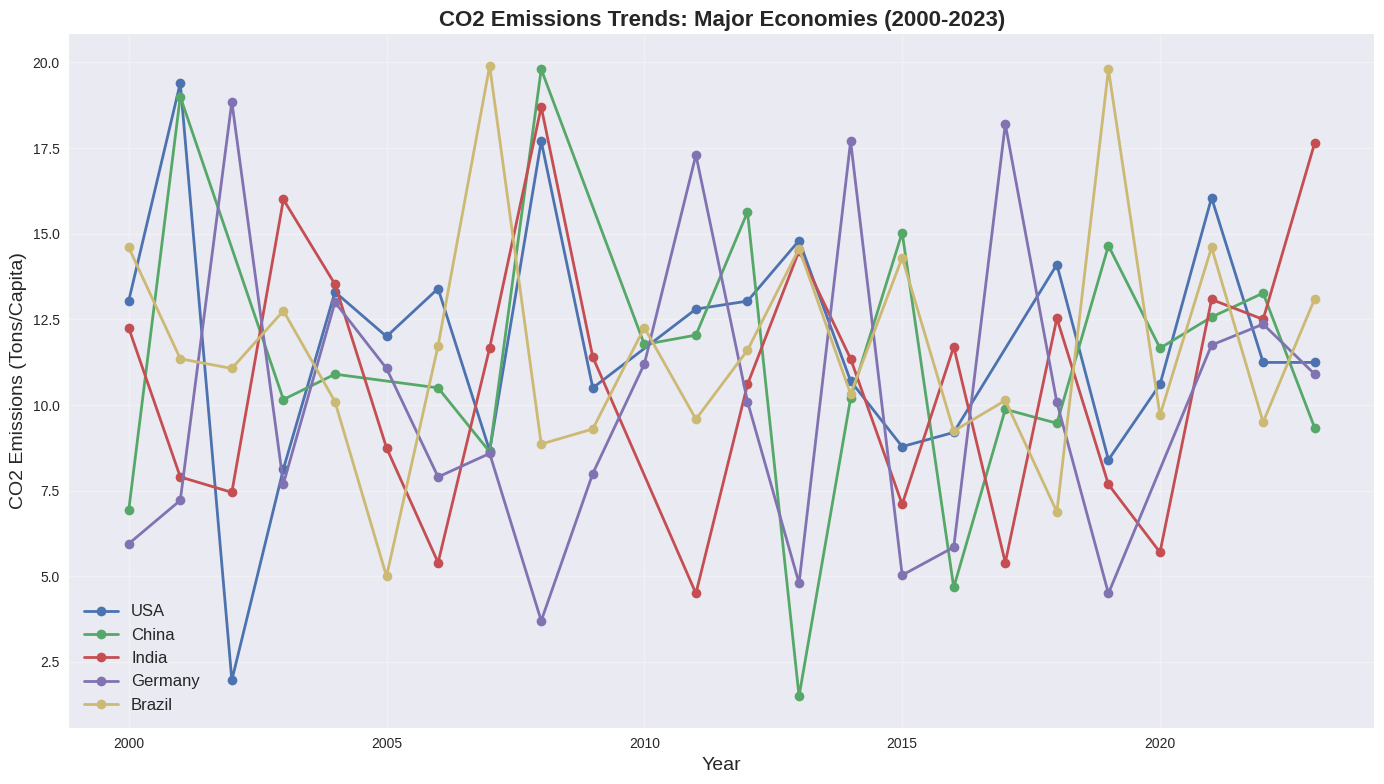

In [ ]:
focus = ['USA','China','India','Germany','Brazil']

# Aggregate by mean in case of multiple entries for (Country, Year)
plot_df = (
    df[df['Country'].isin(focus)]
    .groupby(['Country', 'Year'], as_index=False)['CO2 Emissions (Tons/Capita)']
    .mean()
    .sort_values(['Country', 'Year'])
)

plt.figure(figsize=(14, 8))

for c in focus:
    subset = plot_df[plot_df['Country'] == c]
    plt.plot(subset['Year'], subset['CO2 Emissions (Tons/Capita)'],
             marker='o', label=c, linewidth=2, markersize=7)

plt.title("CO2 Emissions Trends: Major Economies (2000-2023)", fontsize=16, fontweight='bold')
plt.xlabel("Year", fontsize=14)
plt.ylabel("CO2 Emissions (Tons/Capita)", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


This plot illustrates the annual per capita CO2 emissions for the five largest economies in the dataset—USA, China, India, Germany, and Brazil—over the period 2000 to 2023.


*   Variability: All countries show significant year-to-year fluctuations, indicating sensitivity to economic cycles, energy policies, or data limitations.

*   Relative Levels: The USA consistently has among the highest per capita emissions, while India and Brazil tend to be lower, with China and Germany in between.

*   Global Implication: The lack of a unified declining trend across these major economies highlights the challenge in achieving sustained global CO2 reductions and underscores the need for stronger, more consistent climate policies.

##CO2 Emissions Trend Over Time - Developed vs Developing Countries

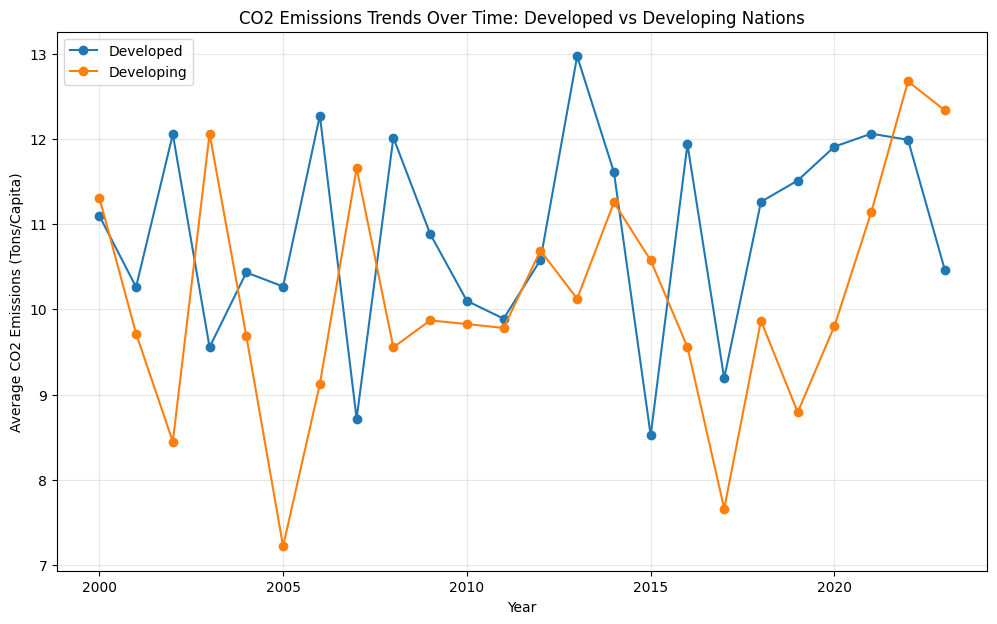

Summary statistics of CO2 Emissions by Development Level:
                   count       mean       std  min   25%   50%    75%   max
Development_Level                                                          
Developed          395.0  10.914684  5.664368  0.5  5.85  11.2  15.95  20.0
Developing         605.0  10.106612  5.563507  0.5  5.30  10.0  14.90  20.0


In [3]:
# World Bank 2024 country classification
developed_countries = ['USA', 'UK', 'France', 'Germany', 'Japan', 'Canada']
developing_countries = [c for c in df['Country'].unique() if c not in developed_countries]

# Add Development_Level column
def classify_dev(country):
    if country in developed_countries:
        return 'Developed'
    else:
        return 'Developing'

df['Development_Level'] = df['Country'].apply(classify_dev)

# Compute average CO2 emissions by Development Level and Year
co2_dev_trends = df.groupby(['Year', 'Development_Level'])['CO2 Emissions (Tons/Capita)'].mean().reset_index()

# Plot trends
plt.figure(figsize=(12, 7))
for dev_level in ['Developed', 'Developing']:
    subset = co2_dev_trends[co2_dev_trends['Development_Level'] == dev_level]
    plt.plot(subset['Year'], subset['CO2 Emissions (Tons/Capita)'], marker='o', label=dev_level)

plt.title('CO2 Emissions Trends Over Time: Developed vs Developing Nations')
plt.xlabel('Year')
plt.ylabel('Average CO2 Emissions (Tons/Capita)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print summary statistics
summary_stats = df.groupby('Development_Level')['CO2 Emissions (Tons/Capita)'].describe()
print("Summary statistics of CO2 Emissions by Development Level:")
print(summary_stats)


We follow the World Bank's 2024 classification to distinguish developed vs. developing nations. This increases objectivity and reproducibility, and adjusts for countries that recently transitioned to higher income brackets.

This plot compares average annual CO2 emissions per capita between developed and developing nations from 2000 to 2023.

*   Developed countries generally maintain higher per capita

*   Emissions, reflecting their higher energy consumption patterns and industrialization status.

*   Developing countries emit less per capita on average but show a slightly rising trend, illustrating ongoing industrial growth and energy needs.

*   The fluctuating patterns for both groups reflect economic cycles, policy shifts, and external factors influencing emissions year-to-year.

*   The narrowing gap in recent years highlights the growing emissions footprint of developing economies, emphasizing the need for global cooperation on sustainable development and technology transfer.

##Policy Relevant Metric Analysis

In [4]:
# --- Policy-Relevant Metric Analysis ---

# Split into early (2000-2005) vs recent (2018-2023) periods
early_period = df[df['Year'] <= 2005]
recent_period = df[df['Year'] >= 2018]

policy_metrics = {}
for label, period in [('Early (2000–2005)', early_period), ('Recent (2018–2023)', recent_period)]:
    policy_metrics[label] = {
        'CO2 Emissions (Tons/Capita)': period['CO2 Emissions (Tons/Capita)'].mean(),
        'Renewable Energy (%)': period['Renewable Energy (%)'].mean(),
        'Forest Area (%)': period['Forest Area (%)'].mean(),
        'Sea Level Rise (mm)': period['Sea Level Rise (mm)'].mean(),
        'Extreme Weather Events': period['Extreme Weather Events'].mean()
    }

In [ ]:
# Calculate percentage changes
changes = {}
for metric in policy_metrics['Early (2000–2005)']:
    early_val = policy_metrics['Early (2000–2005)'][metric]
    recent_val = policy_metrics['Recent (2018–2023)'][metric]
    changes[metric] = ((recent_val - early_val) / early_val) * 100

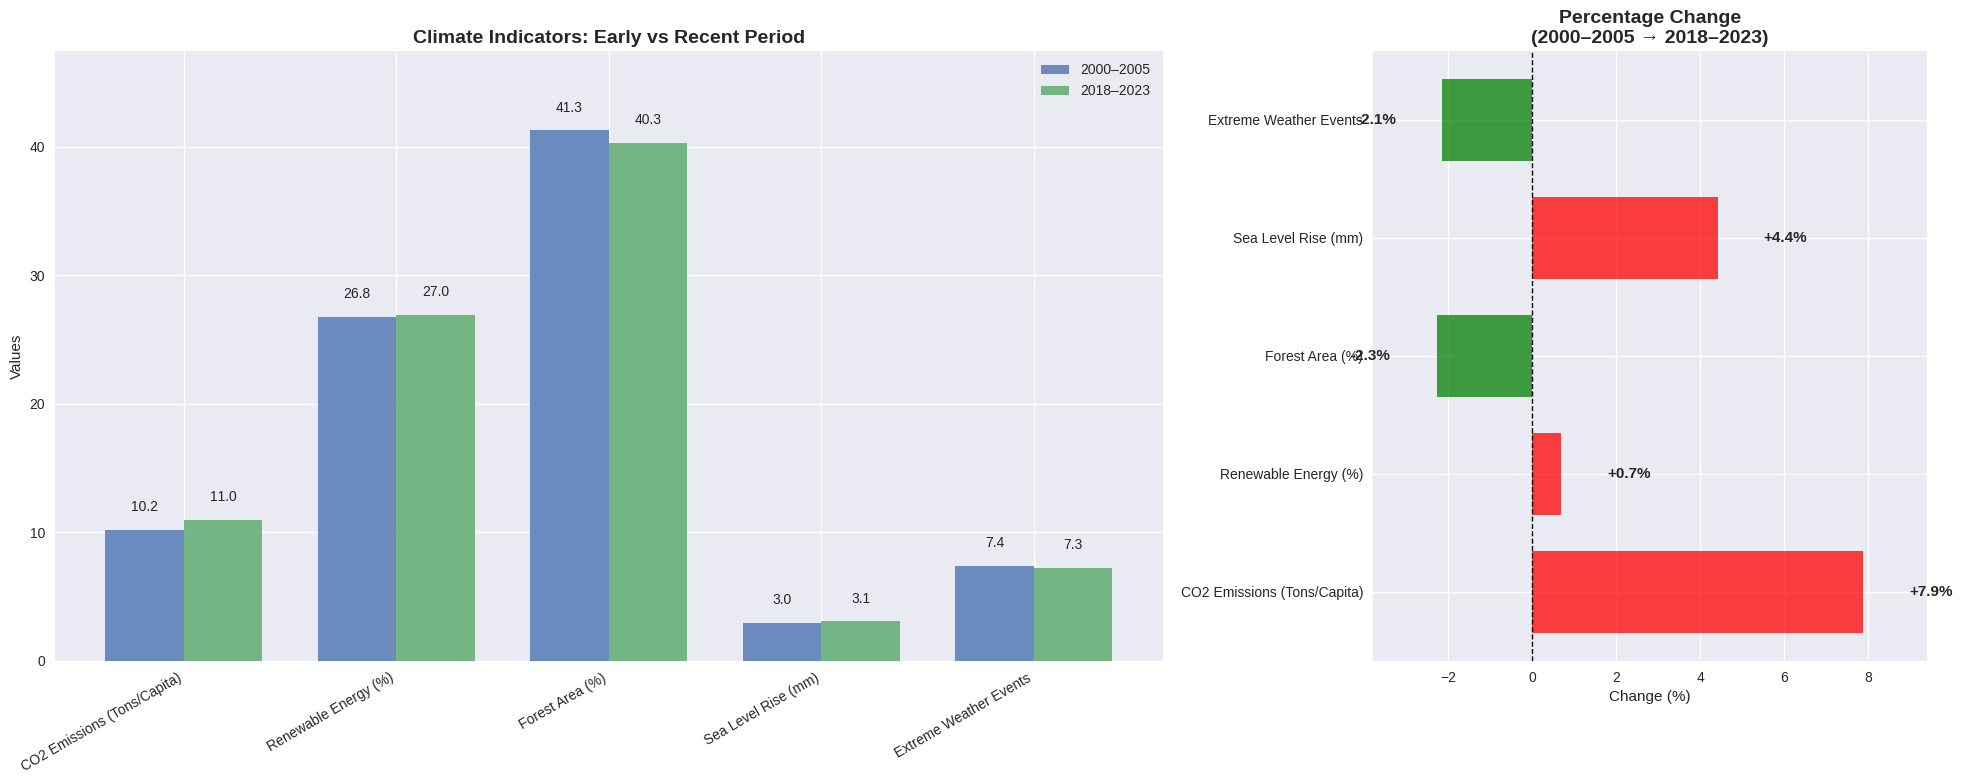

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8), gridspec_kw={'width_ratios':[2,1]})

# Set metrics/values
metrics = list(policy_metrics['Early (2000–2005)'].keys())
early_vals = list(policy_metrics['Early (2000–2005)'].values())
recent_vals = list(policy_metrics['Recent (2018–2023)'].values())

x = np.arange(len(metrics))
width = 0.37

# --- Left: Bar chart, Early vs Recent ---
ax1.bar(x - width/2, early_vals, width, label='2000–2005', alpha=0.8)
ax1.bar(x + width/2, recent_vals, width, label='2018–2023', alpha=0.8)
ax1.set_title("Climate Indicators: Early vs Recent Period", fontsize=14, fontweight='bold')
ax1.set_ylabel("Values")
ax1.set_xticks(x)
ax1.set_xticklabels(metrics, rotation=30, ha='right')
ax1.legend()

# Add value labels above bars
for xi, ev in zip(x, early_vals):
    ax1.text(xi - width/2, ev + 0.03*max(early_vals), f"{ev:.1f}", ha='center', va='bottom', fontsize=10)
for xi, rv in zip(x, recent_vals):
    ax1.text(xi + width/2, rv + 0.03*max(recent_vals), f"{rv:.1f}", ha='center', va='bottom', fontsize=10)

ax1.margins(y=0.15)

# --- Right: % Change Horizontal Bar Chart ---
change_vals = list(changes.values())
colors = ['red' if c > 0 else 'green' for c in change_vals]
ax2.barh(metrics, change_vals, color=colors, alpha=0.74, height=0.7)
ax2.axvline(0, color='black', linestyle='--', lw=1)
ax2.set_title("Percentage Change\n(2000–2005 → 2018–2023)", fontsize=14, fontweight='bold')
ax2.set_xlabel("Change (%)")

for i, (metric, change) in enumerate(zip(metrics, change_vals)):
    x_off = 1.1 if change > 0 else -1.1
    ha_set = 'left' if change > 0 else 'right'
    ax2.text(change + x_off, i, f"{change:+.1f}%", va='center', ha=ha_set, fontsize=11, fontweight='bold')

ax2.margins(x=0.15)

plt.subplots_adjust(wspace=0.35)
plt.tight_layout(rect=[0, 0, 1, 1])

plt.show()


In [ ]:
# --- Text-Based Insights ---
print("\nPOLICY-RELEVANT INSIGHTS")
print("=" * 60)
for metric, change in changes.items():
    if metric in ['CO2 Emissions (Tons/Capita)', 'Sea Level Rise (mm)', 'Extreme Weather Events']:
        status = "WORSENING" if change > 0 else "IMPROVING"
    else:  # Renewable Energy and Forest Area
        status = "IMPROVING" if change > 0 else "DECLINING"
    print(f"{metric:<30}: {change:+.1f}%   → {status}")

# --- Recommendations ---
print("\nPOLICY RECOMMENDATIONS")
print("=" * 60)
print("• CO2 Emissions       :", "Urgent reduction policies needed" if changes['CO2 Emissions (Tons/Capita)'] > 0 else "On a positive trajectory")
print("• Renewable Energy    :", "Accelerate investment; growth pace insufficient" if changes['Renewable Energy (%)'] < 5 else "Progressing well")
print("• Forest Conservation :", "Critical – stop deforestation immediately" if changes['Forest Area (%)'] < 0 else "Maintaining or expanding coverage")
print("• Sea Level Rise      :", "Prepare for adaptation; rise is accelerating" if changes['Sea Level Rise (mm)'] > 0 else "Stable conditions")
print("• Extreme Weather     :", "Strengthen disaster resilience policies" if changes['Extreme Weather Events'] > 0 else "Events reducing – maintain resilience")

# --- Final Summary ---
print("\nFINAL SUMMARY")
print("=" * 60)
print(f"Dataset: {len(df)} records from {df['Country'].nunique()} countries ({df['Year'].min()}–{df['Year'].max()})")
print(f"Top sustainability performers: {country_summary.head(3).index.tolist()}")
biggest_challenge = max(changes.items(), key=lambda x: abs(x[1]))
print(f"Biggest climate challenge: {biggest_challenge[0]} ({biggest_challenge[1]:+.1f}% change)")
print("Key Insight: Global climate action must accelerate across all indicators.")



POLICY-RELEVANT INSIGHTS
CO2 Emissions (Tons/Capita)   : +7.9%   → WORSENING
Renewable Energy (%)          : +0.7%   → IMPROVING
Forest Area (%)               : -2.3%   → DECLINING
Sea Level Rise (mm)           : +4.4%   → WORSENING
Extreme Weather Events        : -2.1%   → IMPROVING

POLICY RECOMMENDATIONS
• CO2 Emissions       : Urgent reduction policies needed
• Renewable Energy    : Accelerate investment; growth pace insufficient
• Forest Conservation : Critical – stop deforestation immediately
• Sea Level Rise      : Prepare for adaptation; rise is accelerating
• Extreme Weather     : Events reducing – maintain resilience

FINAL SUMMARY
Dataset: 1000 records from 15 countries (2000–2023)
Top sustainability performers: ['Mexico', 'Germany', 'China']
Biggest climate challenge: CO2 Emissions (Tons/Capita) (+7.9% change)
Key Insight: Global climate action must accelerate across all indicators.
